In [1]:
import numpy as np
from sklearn.decomposition import PCA

In [2]:
filename = 'COMPILE.csv'
dense_coding_table = []
for line in open(filename):
    dense_coding_table.append(line.strip('\n').split(','))
for x in dense_coding_table[:10]:
    print(x)

['verse', 'eng', 'cym', 'deu', 'fin', 'hat', 'hau', 'hin', 'jav', 'pol', 'tur', 'yor']
['40012040', 'in', 'yn', 'in', '-ssa', 'nan', 'cikin', 'mẽ', 'ing', 'w', '-inda', 'ninu']
['40024040', 'in', 'yn', 'auf', '-lla', 'nan', 'a', 'mẽ', 'ing', 'na', '-da', 'li']
['40026006', 'in', 'yn', 'in', '-ssa', '--', 'a', 'mẽ', 'ing', 'w', '-da', 'ni']
['40027038', 'on', 'ar', 'zur', '-lle', 'sou', 'a', 'par', 'ing', 'z', '-inda', 'li']
['41001004', 'in', 'yn', 'in', '-ssa', 'nan', 'a', 'mẽ', 'ing', 'na', '-da', 'ni']
['41001019', 'in', 'yn', 'in', '-ssa', 'nan', 'cikin', 'par', 'ing', 'w', '-da', 'ninu']
['41006047', 'on', 'ar', 'auf', '--', '--', 'a', 'par', 'ing', 'na', '-da', 'ni']
['41009033', 'in', 'NULL', 'in', '--', '--', '--', '--', 'ing', 'w', '--', 'ninu']
['41013008', 'in', 'mewn', '--', '-lla', 'NULL', 'a', '--', 'ing', 'w', '--', 'ni']


In [3]:
def get_sparse_coding(dense_coding_table, no_response):
    languages = dense_coding_table[0][1:]
    sparse_dict = { language : {} for language in languages }
    sparse_coding_table = []
    for i,language in enumerate(languages, start=1):
        for row in dense_coding_table[1:]:
            for morpheme in row[i].split(' '):
                if morpheme == no_response: continue
                elif morpheme not in sparse_dict[language]: 
                    sparse_dict[language][morpheme] = len(sparse_dict[language])
    header = [language + '_' + morpheme for language in languages 
              for morpheme in sorted(sparse_dict[language], key = lambda k : sparse_dict[language][k])]
    for row in dense_coding_table[1:]:
        sparse_row = []
        for i,language in enumerate(languages, start=1):
            sparse_row_i = [0 for j in range(len(sparse_dict[language]))]
            for morpheme in row[i].split(' '):
                if morpheme == no_response: continue
                else:
                    index = sparse_dict[language][morpheme]
                    sparse_row_i[index] = 1
            sparse_row.extend(sparse_row_i)
        sparse_coding_table.append(sparse_row)
    return header, sparse_coding_table, sparse_dict
            

header, sparse_coding_table, sparse_dict = get_sparse_coding(dense_coding_table, no_response = '--')
print('>>> sparse dict', sparse_dict)
print('>>> header', header)
for i in sparse_coding_table[:10]:
    print(i)

>>> sparse dict {'eng': {'in': 0, 'on': 1, 'at': 2, 'by': 3}, 'cym': {'yn': 0, 'ar': 1, 'NULL': 2, 'mewn': 3, 'wrth': 4}, 'deu': {'in': 0, 'auf': 1, 'zur': 2, 'vor': 3, 'an': 4}, 'fin': {'-ssa': 0, '-lla': 1, '-lle': 2, 'NULL': 3}, 'hat': {'nan': 0, 'sou': 1, 'NULL': 2, 'bò_la': 3}, 'hau': {'cikin': 0, 'a': 1, 'kan': 2, 'ciki': 3, 'NULL': 4}, 'hin': {'mẽ': 0, 'par': 1, 'NULL': 2, 'ke': 3, 'pas': 4, 'kinare': 5}, 'jav': {'ing': 0, 'sacedhaké': 1, 'sacedhaking': 2, 'pinggir': 3, 'sajroning': 4, 'sakiwa': 5, 'tengené': 6}, 'pol': {'w': 0, 'na': 1, 'z': 2, 'u': 3, 'przy': 4}, 'tur': {'-inda': 0, '-da': 1}, 'yor': {'ninu': 0, 'li': 1, 'ni': 2, 'lori': 3, 'lẹhin': 4, 'sinu': 5, 'leti': 6}}
>>> header ['eng_in', 'eng_on', 'eng_at', 'eng_by', 'cym_yn', 'cym_ar', 'cym_NULL', 'cym_mewn', 'cym_wrth', 'deu_in', 'deu_auf', 'deu_zur', 'deu_vor', 'deu_an', 'fin_-ssa', 'fin_-lla', 'fin_-lle', 'fin_NULL', 'hat_nan', 'hat_sou', 'hat_NULL', 'hat_bò_la', 'hau_cikin', 'hau_a', 'hau_kan', 'hau_ciki', 'hau_N

In [5]:
P = PCA()
coordinates = P.fit_transform(sparse_coding_table)
print(P.explained_variance_ratio_)

[2.98193843e-01 1.07942835e-01 8.45334564e-02 6.31197074e-02
 5.56342033e-02 5.34152460e-02 4.84719562e-02 3.71088250e-02
 3.47477770e-02 2.61367434e-02 2.39177976e-02 2.28331419e-02
 2.05826360e-02 1.73000263e-02 1.43989189e-02 1.27988728e-02
 1.16400858e-02 9.84647976e-03 9.34957833e-03 8.08327626e-03
 7.19969161e-03 5.58471581e-03 4.91788796e-03 4.42425457e-03
 3.96929304e-03 2.86230927e-03 2.53696162e-03 2.35217269e-03
 1.93297368e-03 1.39417458e-03 8.75029374e-04 6.16315225e-04
 4.50776308e-04 3.15364675e-04 2.05773420e-04 1.49372296e-04
 8.95549677e-05 6.79717153e-05 2.77501494e-33 1.25220728e-33
 1.25220728e-33 1.25220728e-33 1.25220728e-33 1.25220728e-33
 1.25220728e-33]


-1.3115719657780487 -0.25934974777259157 40012040
-0.074311469394992 1.3935990587028269 40024040
-1.5488200540065291 -0.39228941268514994 40026006
1.8945094639190503 -1.187442509169562 40027038
-1.2970592167272461 0.26874230155536694 41001004
-1.0819964061559095 -0.6688375372137549 41001019
1.2473201032452461 -0.4321965950341666 41006047
-0.4875988195563762 -0.4258462225566944 41009033
-0.23320419753095922 0.1090309700112268 41013008
2.066522571050568 -0.26603593850399876 41013015
-0.034097899926858 1.3948845138512054 41013016
0.3764390853307096 0.6219226127854204 41013029
-1.2854034240789094 -0.52277292633155 41014003
-1.1066357859596325 0.3596849698022184 41014066
1.8945094639190503 -1.1874425091695622 41015027
-1.3071433632724085 0.4675583188911007 42002008a
0.14483485870404922 0.7845143292665959 42002008b
0.9286416869988183 0.04421709776170166 42003009
-0.034097899926857994 1.3948845138512054 42015025
2.026309001582433 -0.2673213936523765 42017031
1.371310103475251 0.35806605015462

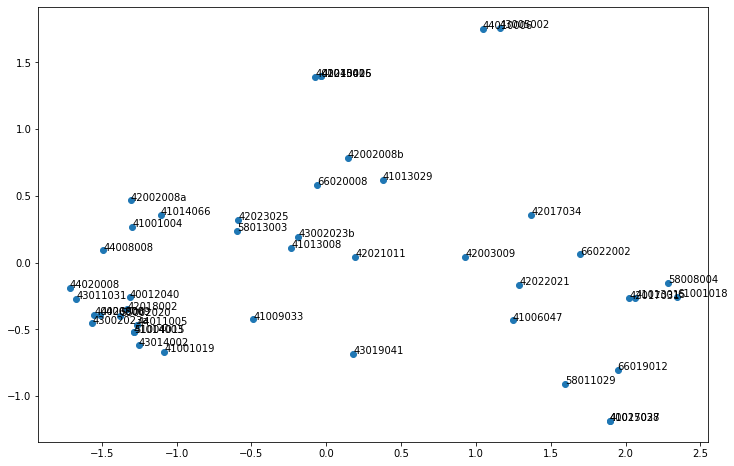

0 eng_in


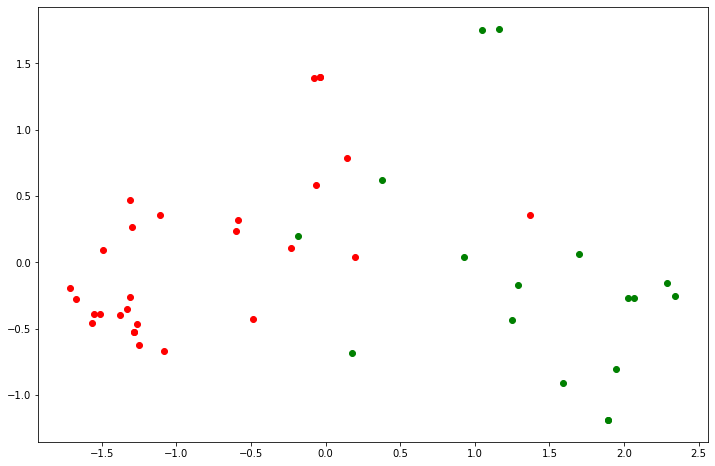

1 eng_on


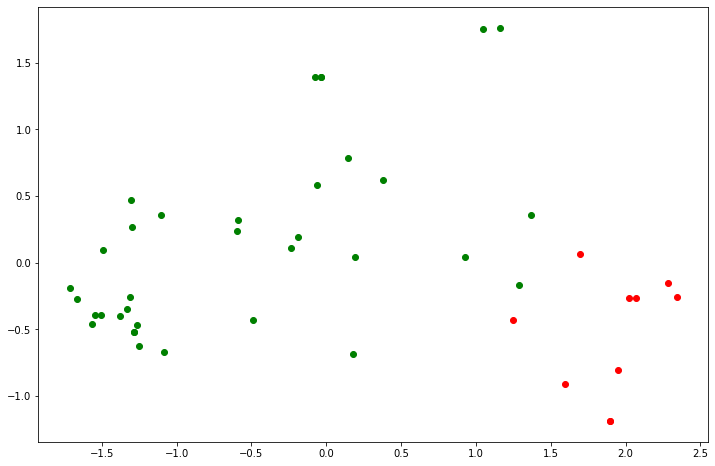

2 eng_at


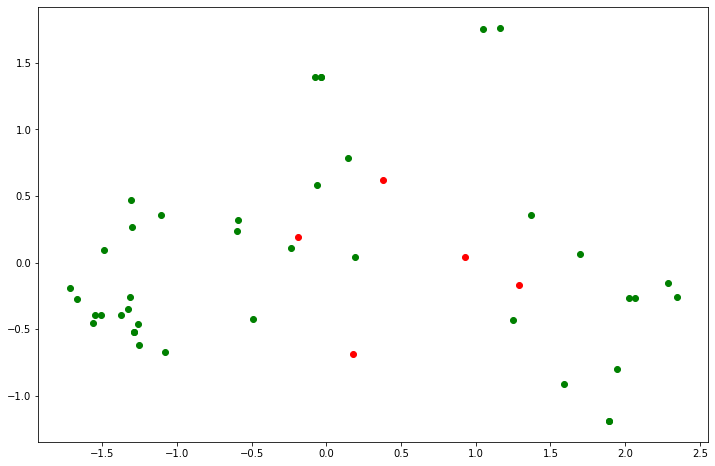

3 eng_by


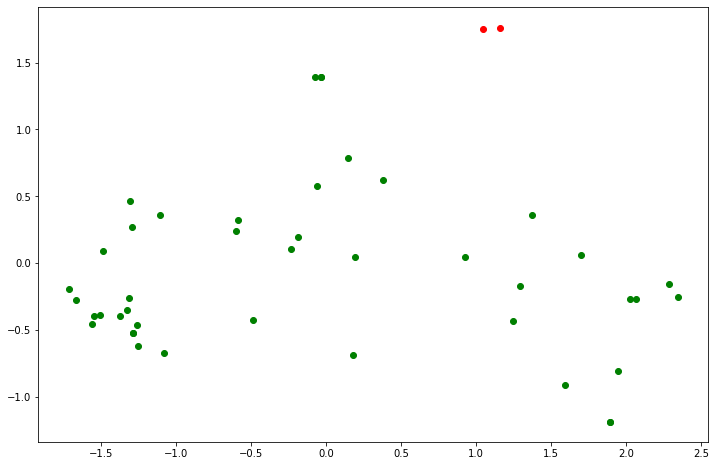

4 cym_yn


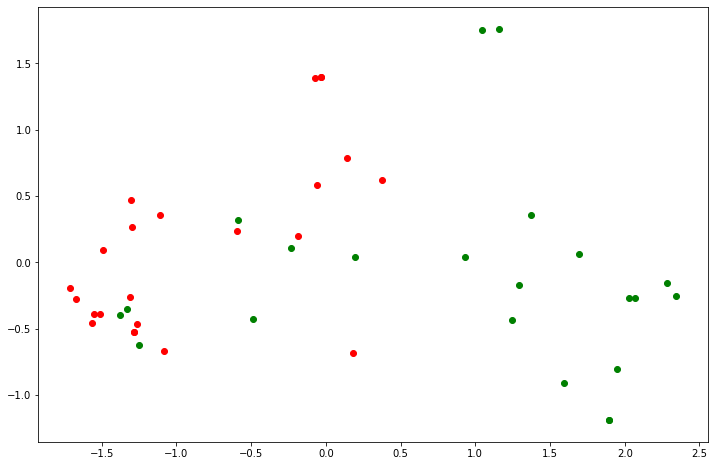

5 cym_ar


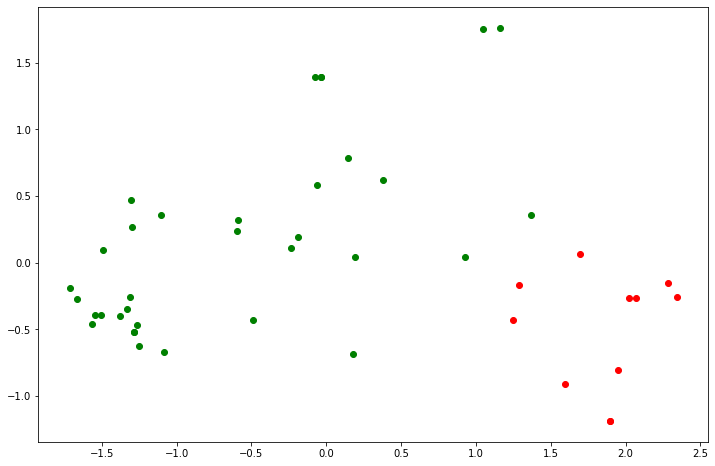

6 cym_NULL


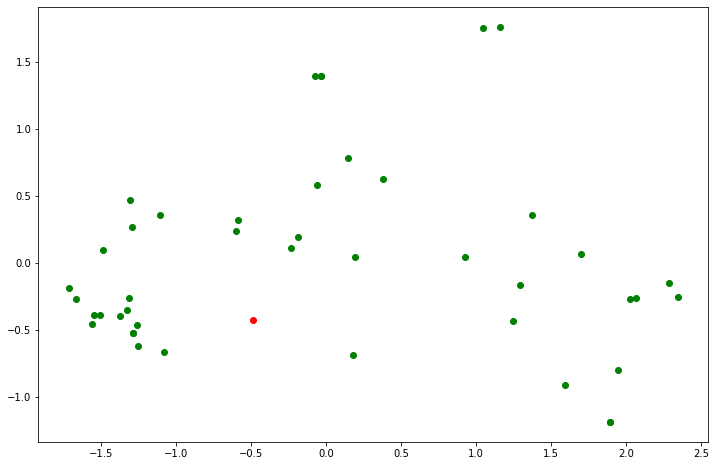

7 cym_mewn


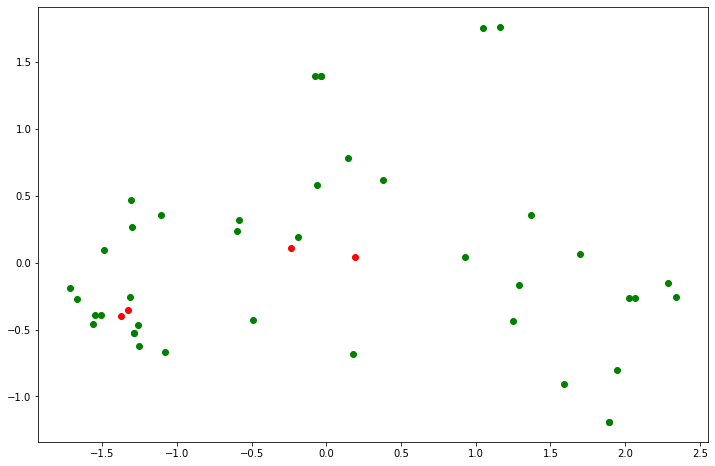

8 cym_wrth


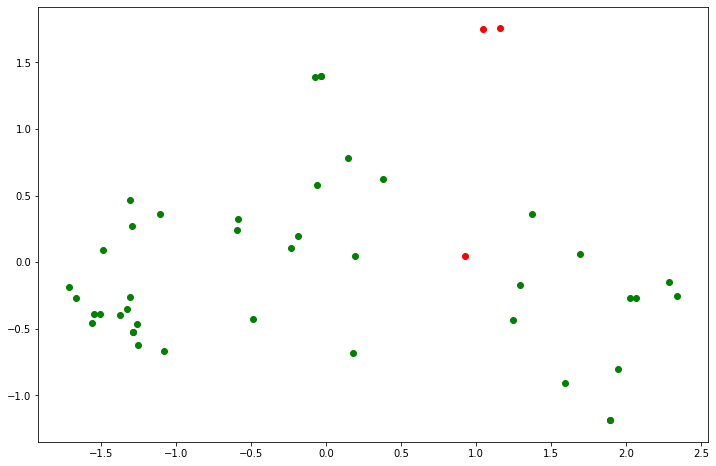

9 deu_in


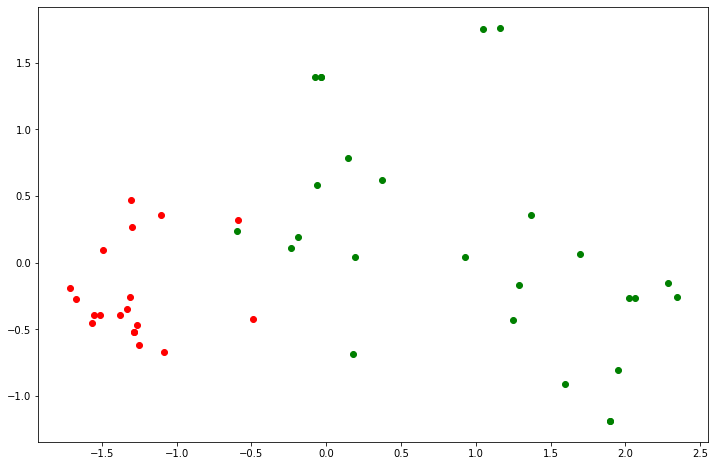

10 deu_auf


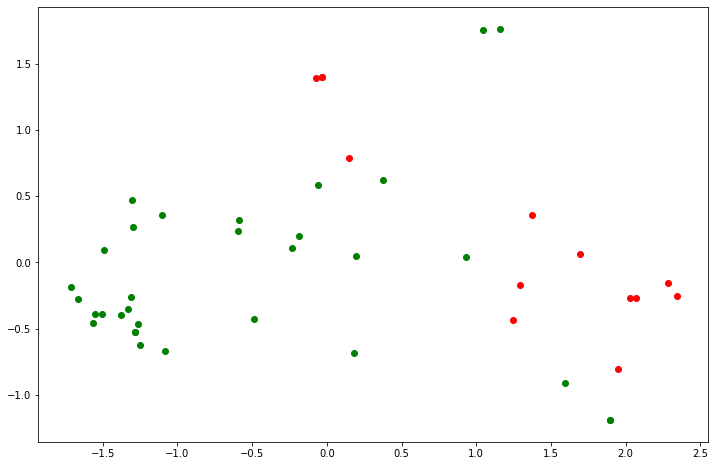

11 deu_zur


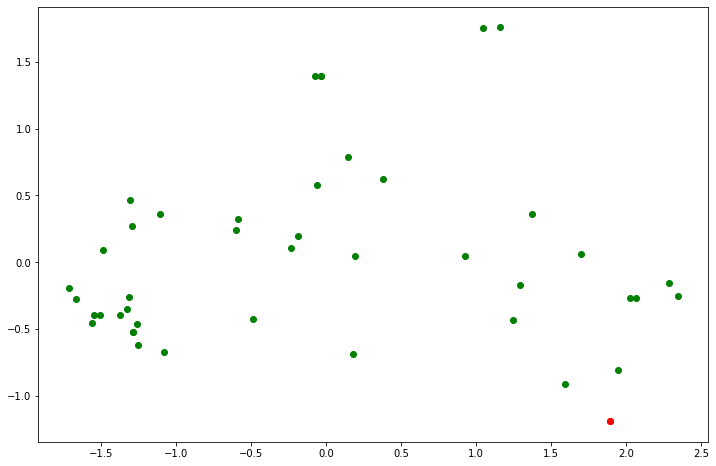

12 deu_vor


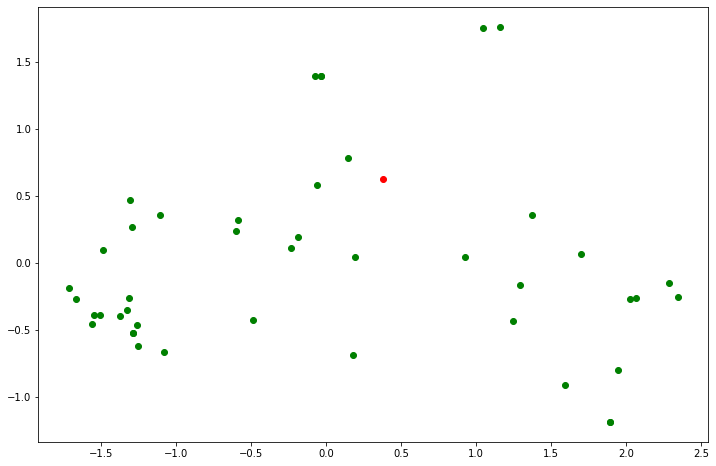

13 deu_an


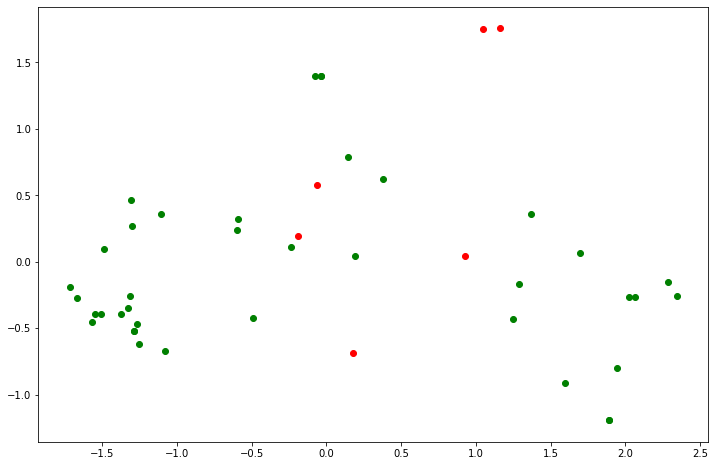

14 fin_-ssa


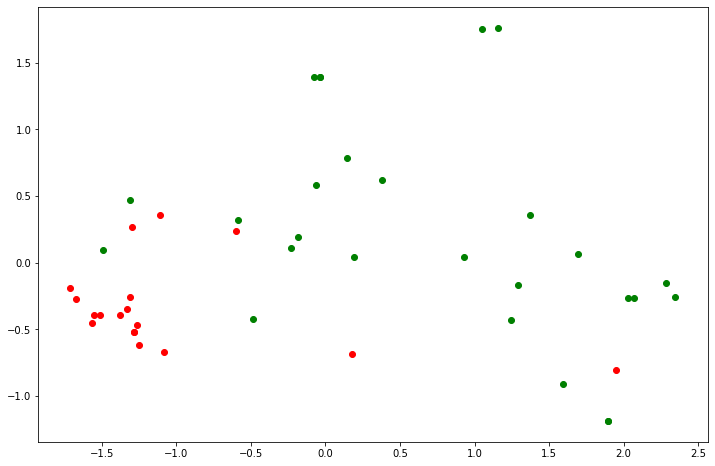

15 fin_-lla


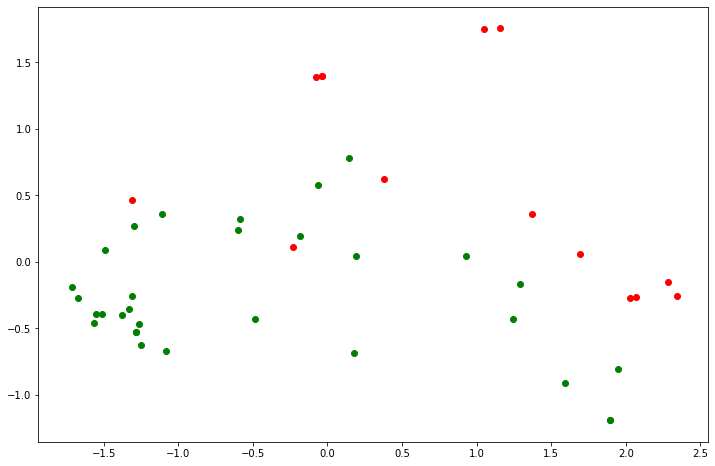

16 fin_-lle


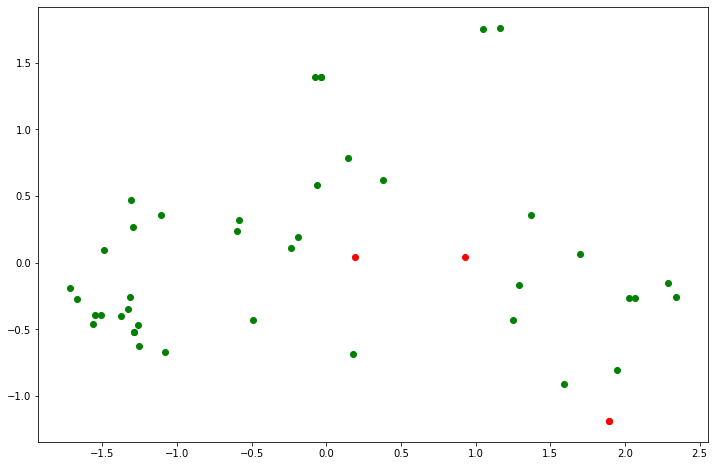

17 fin_NULL


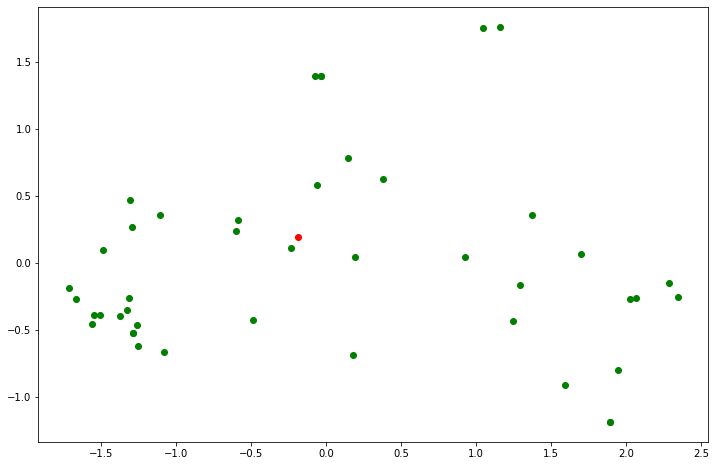

18 hat_nan


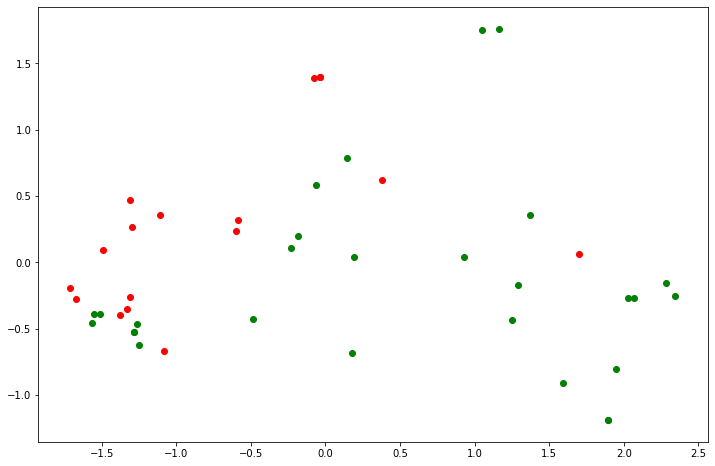

19 hat_sou


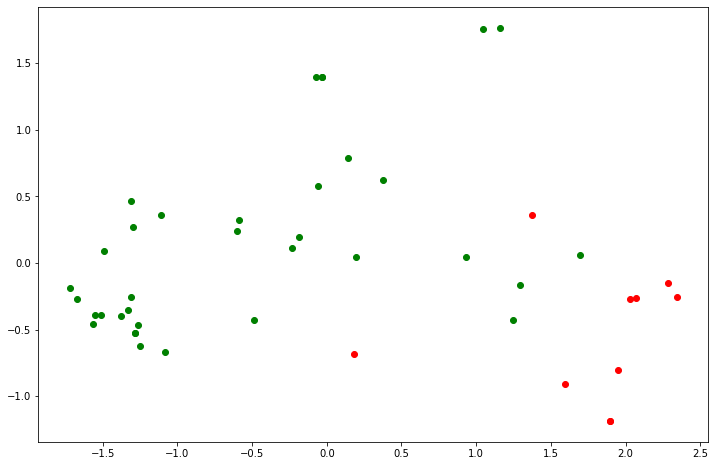

20 hat_NULL


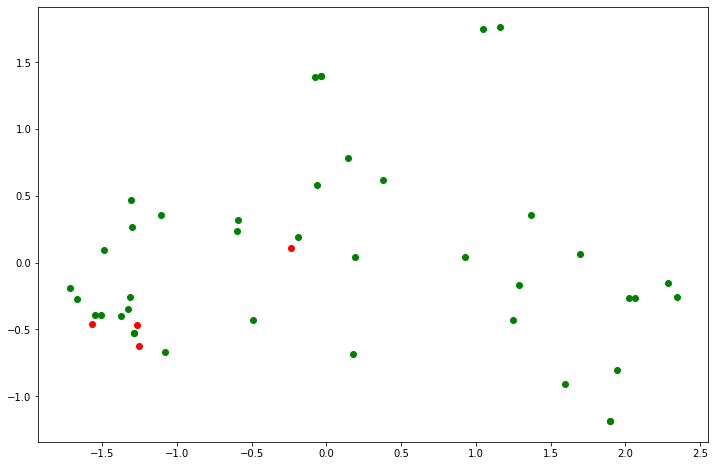

21 hat_bò_la


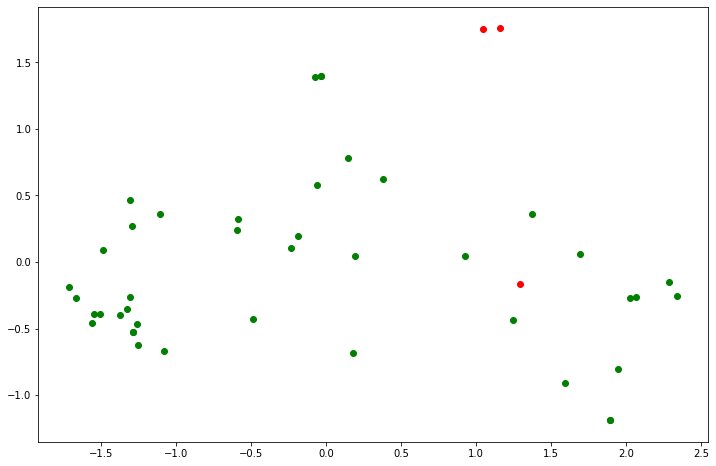

22 hau_cikin


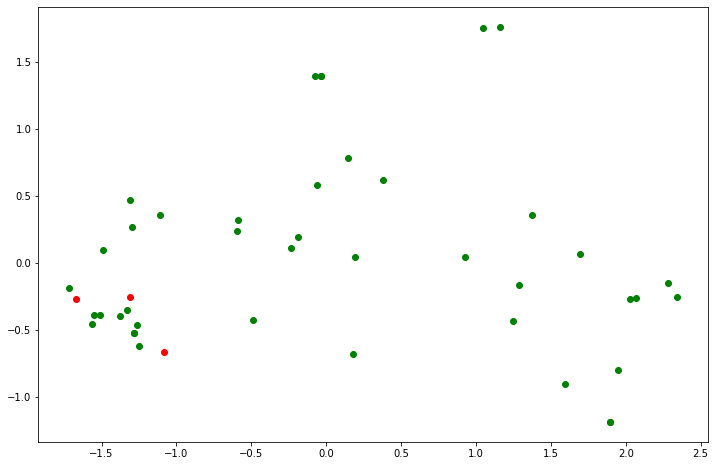

23 hau_a


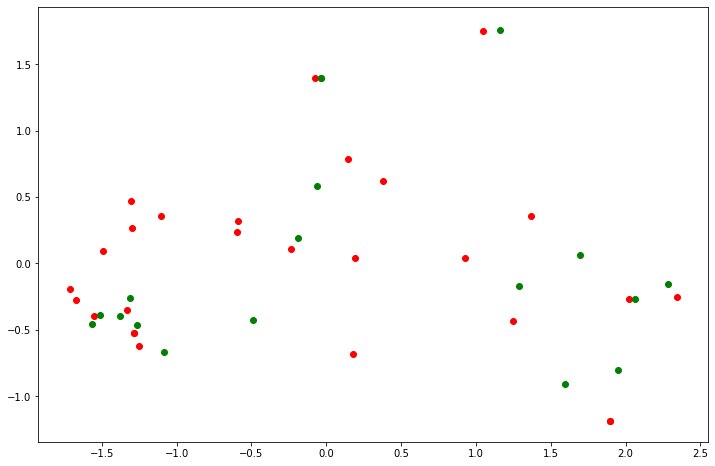

24 hau_kan


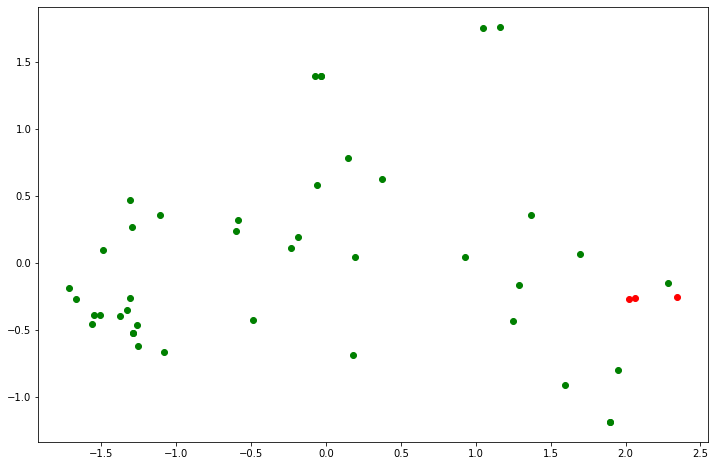

25 hau_ciki


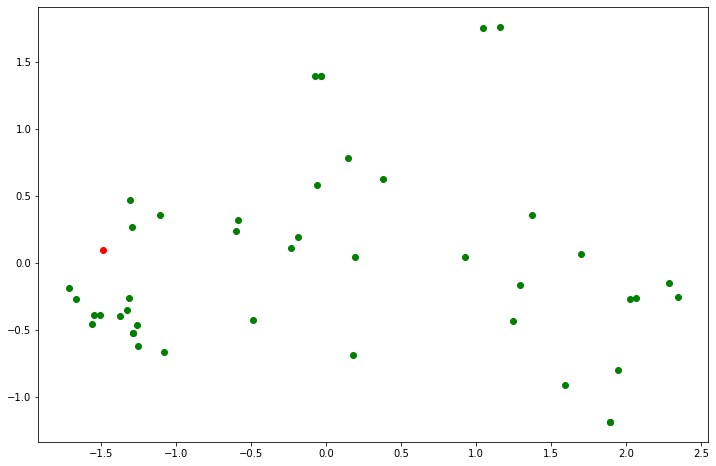

26 hau_NULL


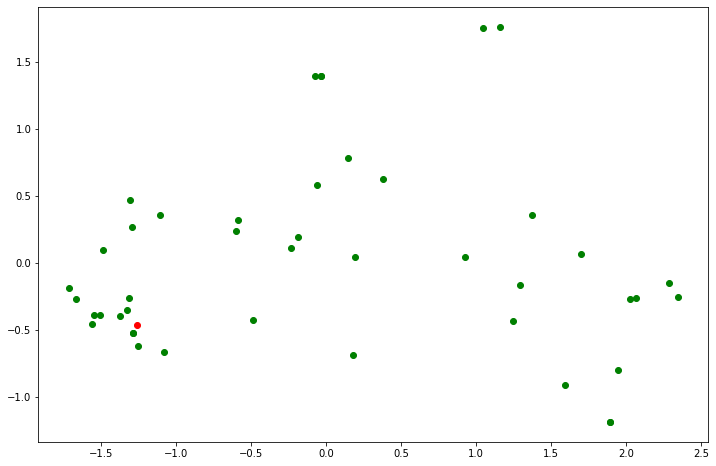

27 hin_mẽ


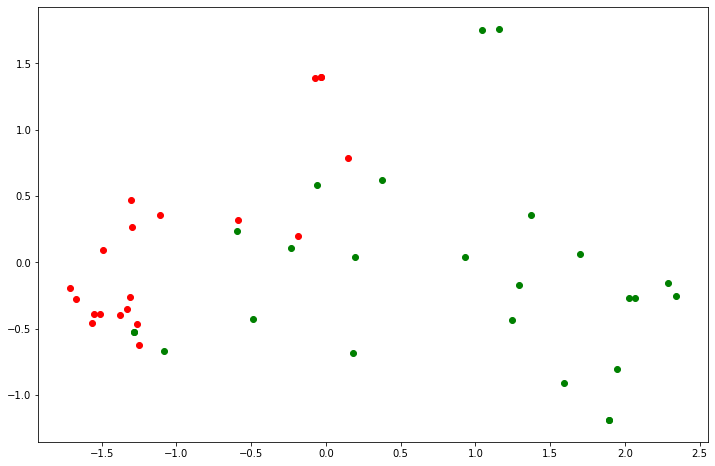

28 hin_par


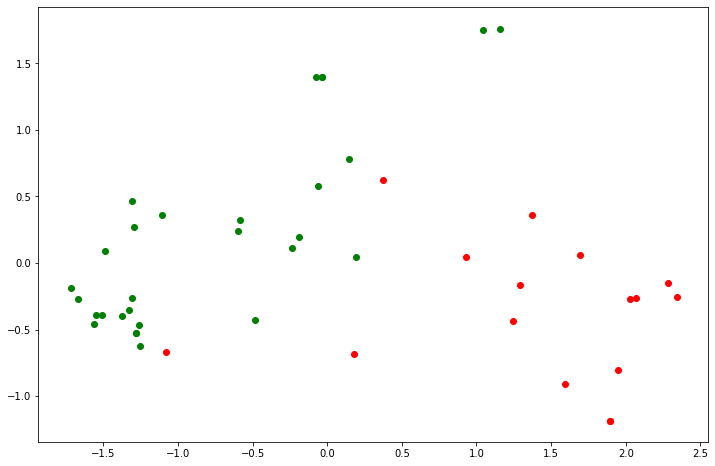

29 hin_NULL


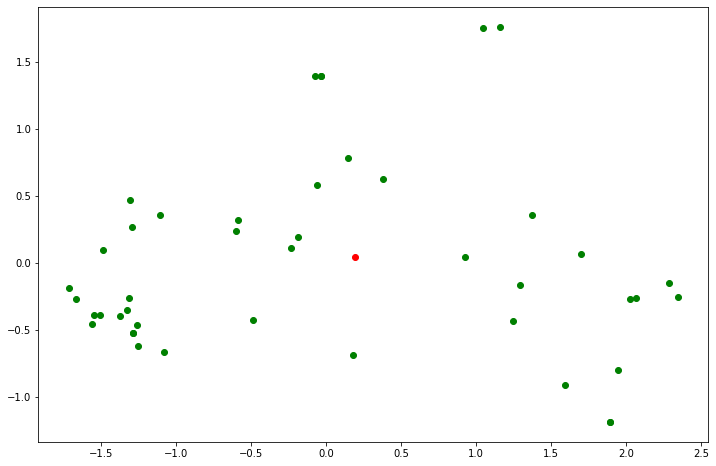

30 hin_ke


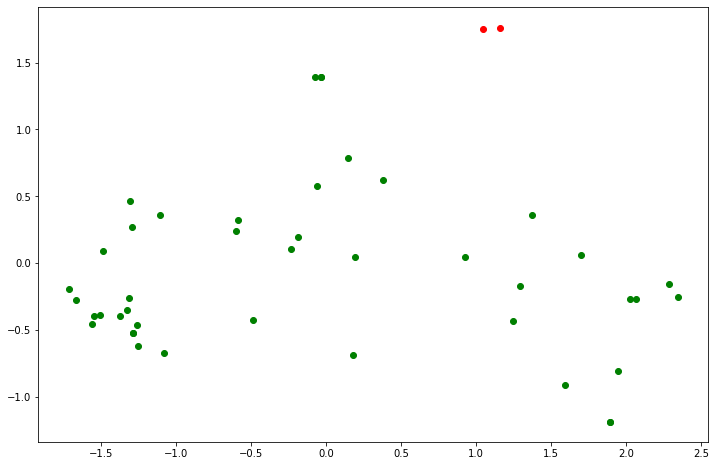

31 hin_pas


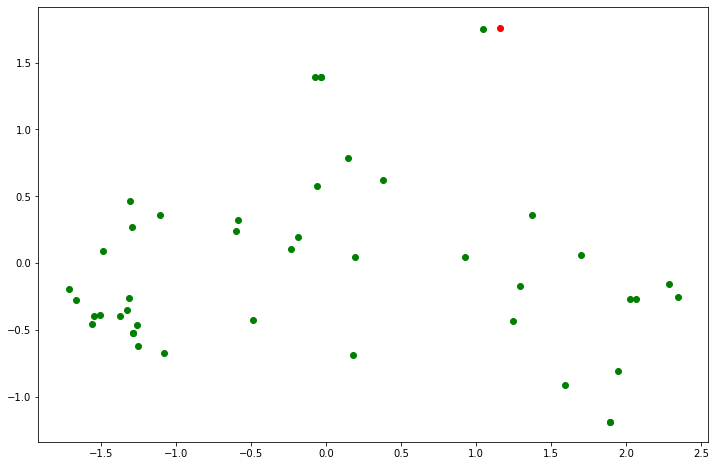

32 hin_kinare


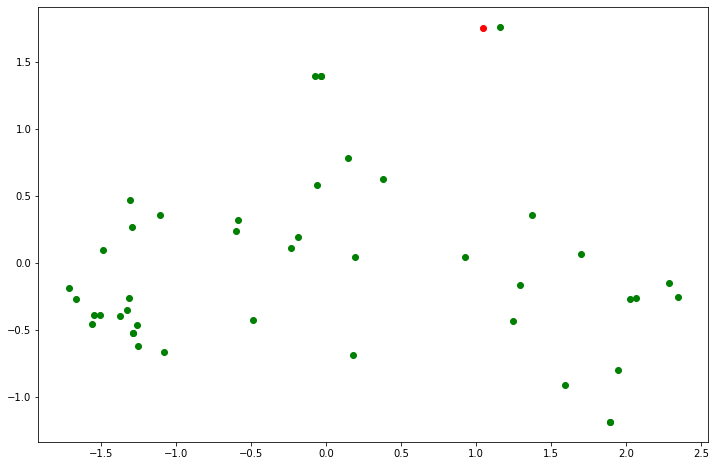

33 jav_ing


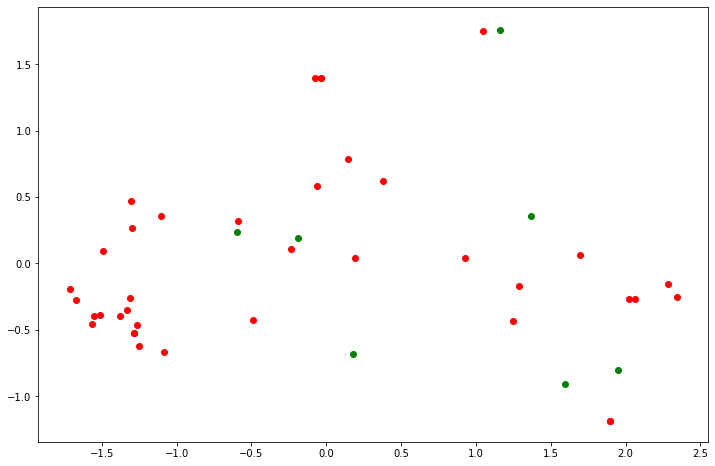

34 jav_sacedhaké


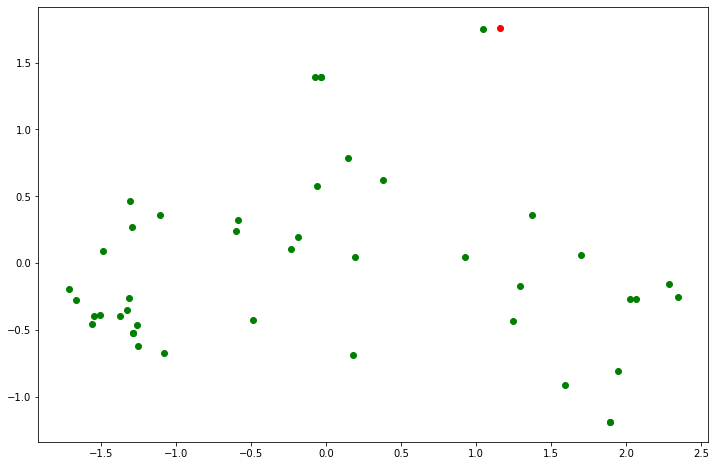

35 jav_sacedhaking


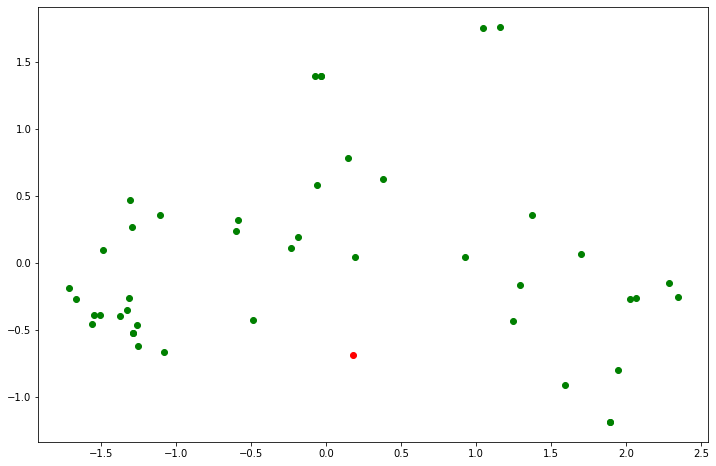

36 jav_pinggir


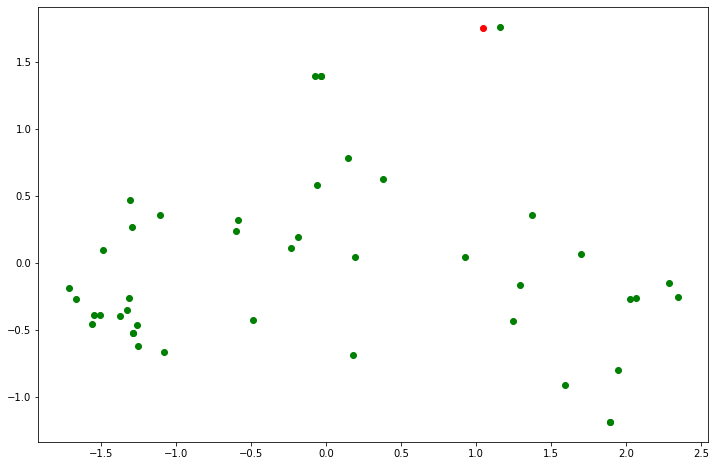

37 jav_sajroning


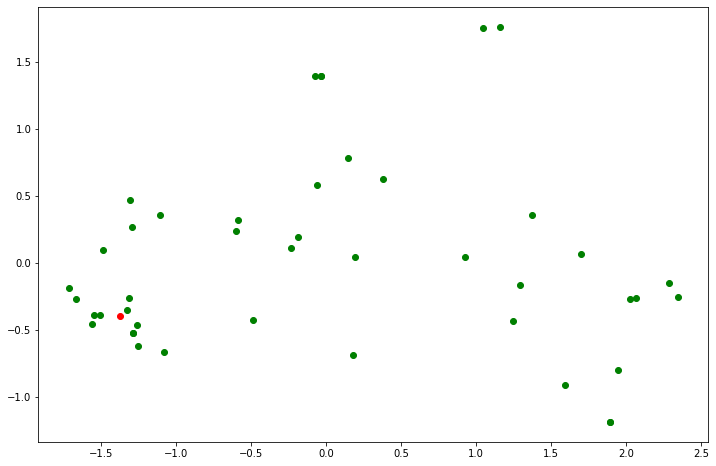

38 jav_sakiwa


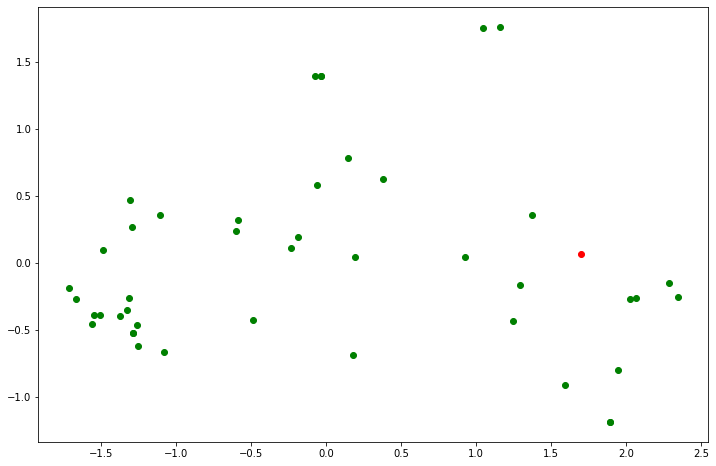

39 jav_tengené


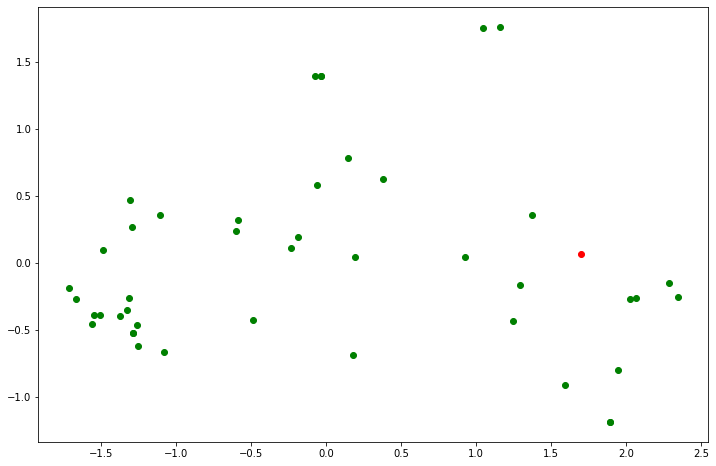

40 pol_w


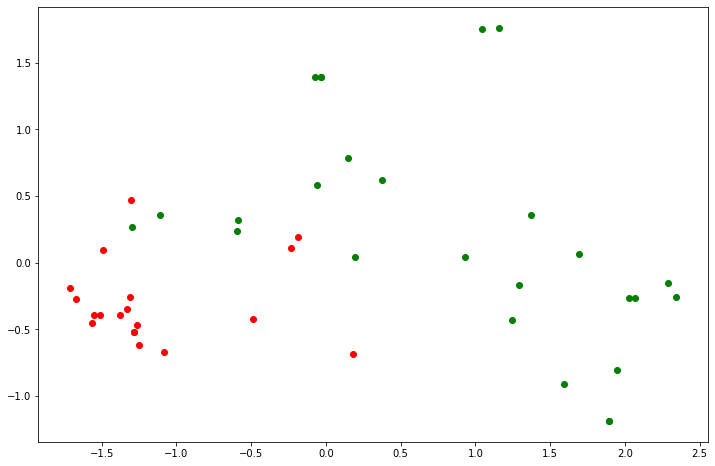

41 pol_na


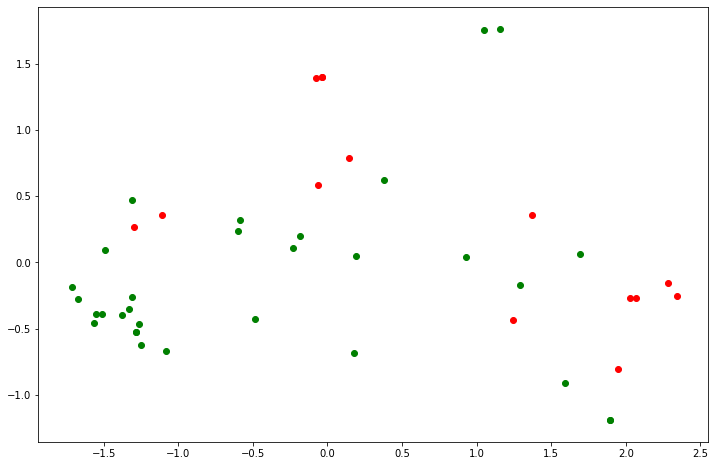

42 pol_z


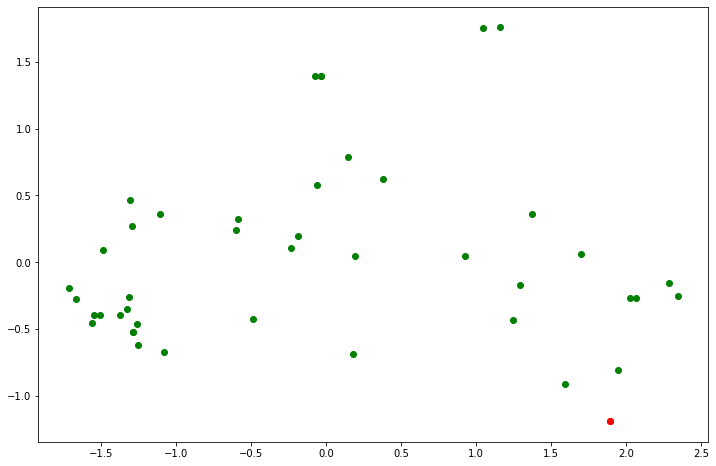

43 pol_u


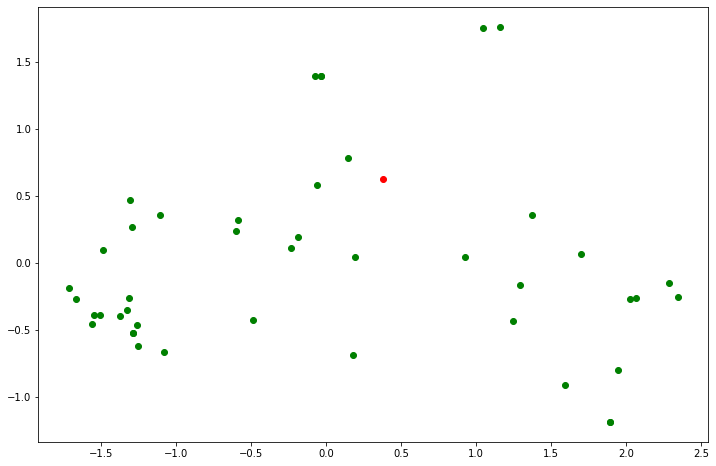

44 pol_przy


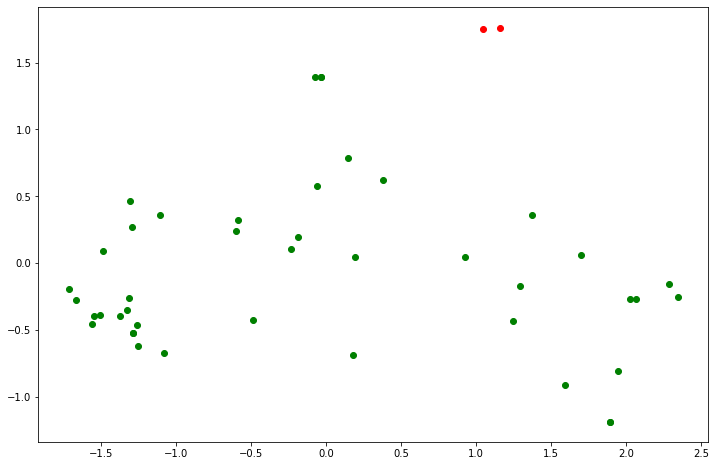

45 tur_-inda


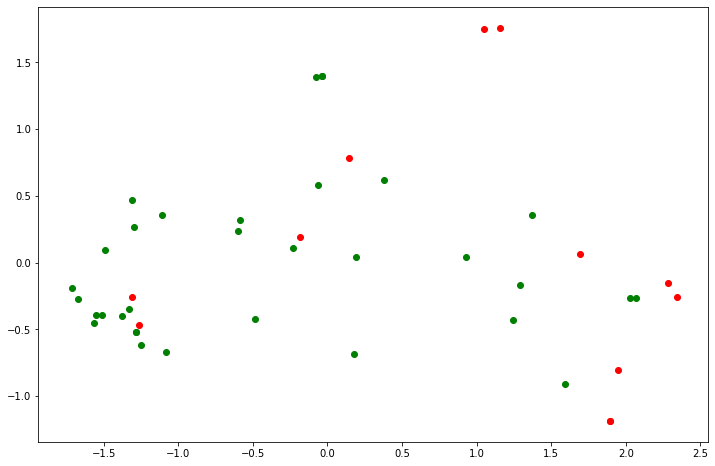

46 tur_-da


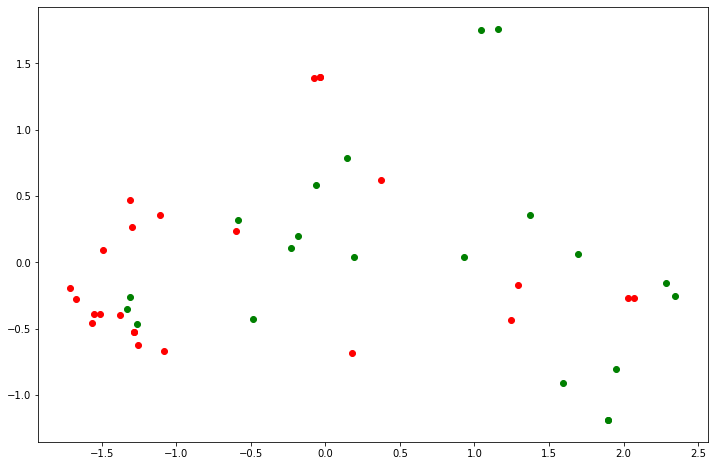

47 yor_ninu


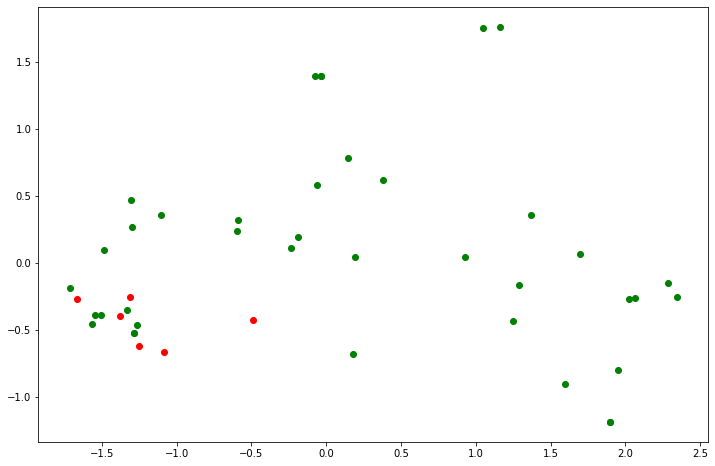

48 yor_li


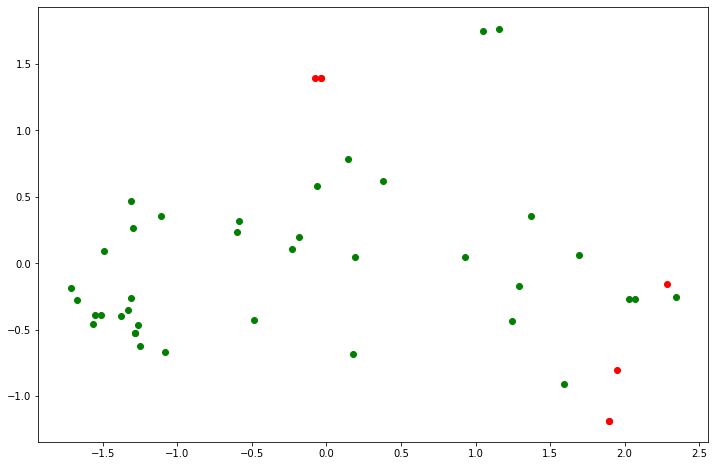

49 yor_ni


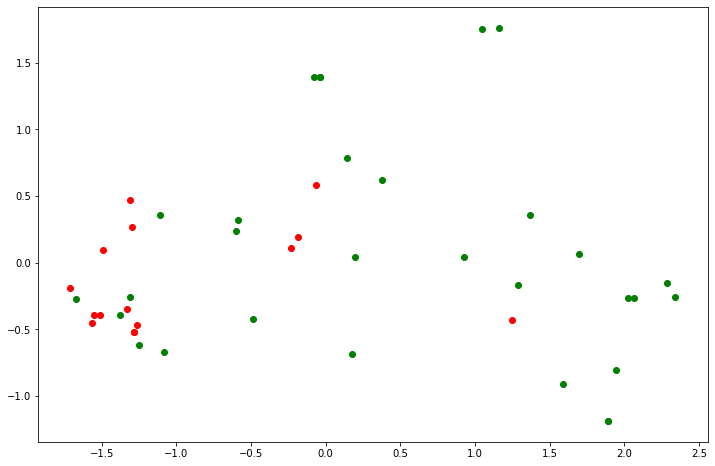

50 yor_lori


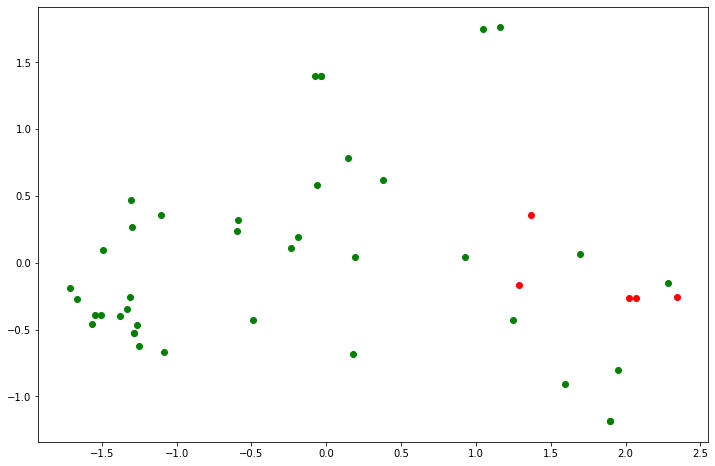

51 yor_lẹhin


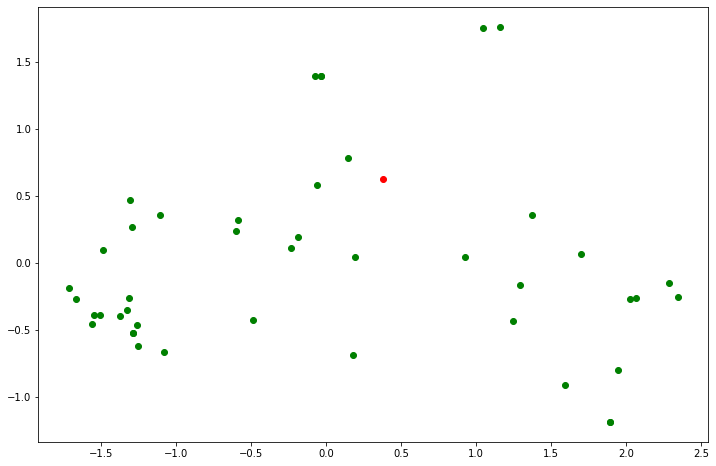

52 yor_sinu


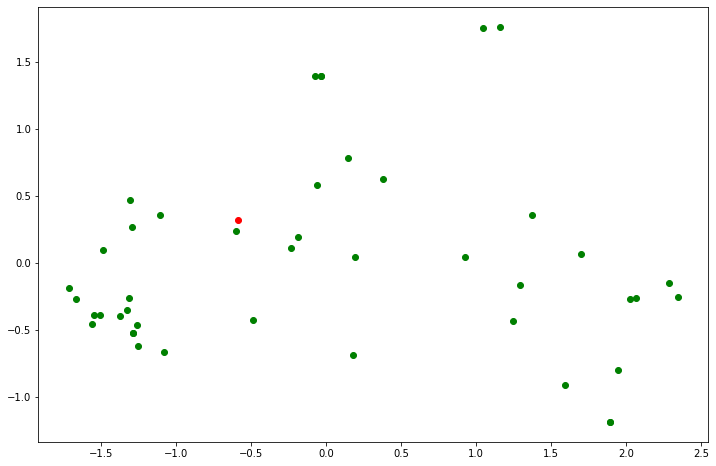

53 yor_leti


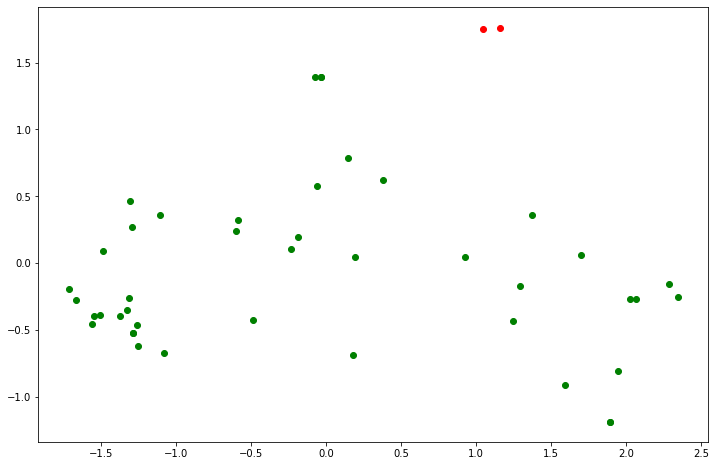

In [6]:
from matplotlib import pyplot as plt
dimension_x = 0
dimension_y = 2
plt.rcParams["figure.figsize"] = (12,8)
plt.scatter(x=coordinates[:,dimension_x],y=coordinates[:,dimension_y])
for i,row in enumerate(dense_coding_table[1:]):
    plt.text(x=coordinates[i,dimension_x],y=coordinates[i,dimension_y],s=dense_coding_table[i+1][0])
    print(coordinates[i,dimension_x],coordinates[i,dimension_y],dense_coding_table[i+1][0])
plt.show()
for i,term in enumerate(header):
    print(i,term)
    present = [j for j,row in enumerate(sparse_coding_table) if row[i] == 1]
    absent  = [j for j,row in enumerate(sparse_coding_table) if row[i] == 0]
    plt.scatter(x=coordinates[present,dimension_x], y=coordinates[present,dimension_y], c = 'r')
    plt.scatter(x=coordinates[absent,dimension_x], y=coordinates[absent,dimension_y], c = 'g')
    plt.show()
    plt.close()